In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("employee_dataset.csv")

Saving employee_dataset.csv to employee_dataset.csv


In [4]:
df.head()

,EmployeeID,Name,Age,Department,Gender,JoiningDate,City,Salary,YearsExperience,PerformanceScore,Attrition
0,1,Employee_280,23.0,IT,M,19-07-2019,seattle,64977.66,5.1,3.0,No
1,2,Employee_103,31.0,HR,M,16-08-2023,Seattle,60424.78,7.0,3.0,Yes
2,3,Employee_172,41.0,Marketing,female,19-04-2020,NaN,50581.07,5.9,2.0,No
3,4,Employee_171,31.0,IT,female,24-06-2019,Seattle,69688.77,0.6,3.0,No
4,5,Employee_74,43.0,Finance,Male,16-04-2018,Boston,40633.13,7.0,5.0,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        310 non-null    int64  
 1   Name              310 non-null    object 
 2   Age               292 non-null    float64
 3   Department        310 non-null    object 
 4   Gender            310 non-null    object 
 5   JoiningDate       310 non-null    object 
 6   City              292 non-null    object 
 7   Salary            291 non-null    float64
 8   YearsExperience   291 non-null    float64
 9   PerformanceScore  292 non-null    float64
 10  Attrition         310 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 26.8+ KB


In [6]:
df.describe()

,EmployeeID,Age,Salary,YearsExperience,PerformanceScore
count,310.000000,292.000000,291.000000,291.000000,292.000000
mean,155.500000,33.472603,65287.616735,5.166323,3.325342
std,89.633513,9.715680,37745.448328,3.082839,0.981080
min,1.000000,21.000000,20000.000000,0.000000,1.000000
25%,78.250000,28.000000,51008.975000,2.850000,3.000000
50%,155.500000,33.000000,61895.690000,5.100000,3.000000
75%,232.750000,37.000000,70533.130000,7.250000,4.000000
max,310.000000,99.000000,414498.600000,15.500000,5.000000


In [7]:
print("Rows and Columns:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Rows and Columns: (310, 11)

Data Types
EmployeeID            int64
Name                 object
Age                 float64
Department           object
Gender               object
JoiningDate          object
City                 object
Salary              float64
YearsExperience     float64
PerformanceScore    float64
Attrition            object
dtype: object

Missing Values
EmployeeID           0
Name                 0
Age                 18
Department           0
Gender               0
JoiningDate          0
City                18
Salary              19
YearsExperience     19
PerformanceScore    18
Attrition            0
dtype: int64


In [8]:
df.head()

,EmployeeID,Name,Age,Department,Gender,JoiningDate,City,Salary,YearsExperience,PerformanceScore,Attrition
0,1,Employee_280,23.0,IT,M,19-07-2019,seattle,64977.66,5.1,3.0,No
1,2,Employee_103,31.0,HR,M,16-08-2023,Seattle,60424.78,7.0,3.0,Yes
2,3,Employee_172,41.0,Marketing,female,19-04-2020,NaN,50581.07,5.9,2.0,No
3,4,Employee_171,31.0,IT,female,24-06-2019,Seattle,69688.77,0.6,3.0,No
4,5,Employee_74,43.0,Finance,Male,16-04-2018,Boston,40633.13,7.0,5.0,No


In [9]:
df.tail()

,EmployeeID,Name,Age,Department,Gender,JoiningDate,City,Salary,YearsExperience,PerformanceScore,Attrition
305,306,Employee_212,21.0,IT,female,20-04-2024,CHICAGO,NaN,4.0,2.0,No
306,307,Employee_68,45.0,Sales,male,30-11-2015,seattle,25830.74,4.4,4.0,No
307,308,Employee_26,NaN,Marketing,MALE,04-09-2024,New york,35674.58,1.0,4.0,Yes
308,309,Employee_197,34.0,IT,Male,06-02-2021,AUSTIN,67676.07,5.1,3.0,No
309,310,Employee_176,28.0,Finance,MALE,21-07-2016,NEW YORK,93276.32,NaN,3.0,Yes


In [10]:
df.sample(5)

,EmployeeID,Name,Age,Department,Gender,JoiningDate,City,Salary,YearsExperience,PerformanceScore,Attrition
208,209,Employee_198,26.0,IT,M,05-10-2023,Seattle,36079.45,3.6,4.0,No
32,33,Employee_15,28.0,Sales,female,10-07-2020,Boston,78555.24,4.7,4.0,No
69,70,Employee_23,25.0,Sales,male,26-07-2021,AUSTIN,58843.47,2.6,NaN,No
272,273,Employee_234,NaN,Sales,MALE,15-08-2015,seattle,62201.90,3.6,3.0,No
260,261,Employee_214,31.0,HR,F,25-07-2023,Boston,NaN,3.2,1.0,No


In [11]:
df.isnull().sum()

,0
EmployeeID,0
Name,0
Age,18
Department,0
Gender,0
JoiningDate,0
City,18
Salary,19
YearsExperience,19
PerformanceScore,18


In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_3009/4057150236.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3009/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df.isnull().sum()

,0
EmployeeID,0
Name,0
Age,0
Department,0
Gender,0
JoiningDate,0
City,0
Salary,0
YearsExperience,0
PerformanceScore,0


In [15]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Duplicate Rows: 0
Rows after removing duplicates: 310


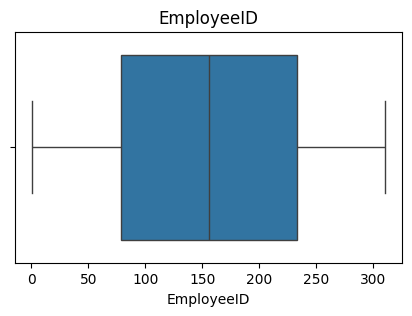

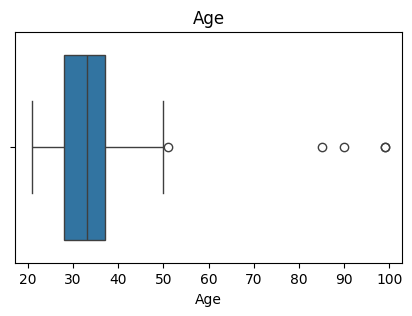

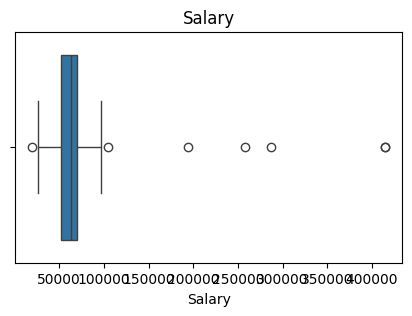

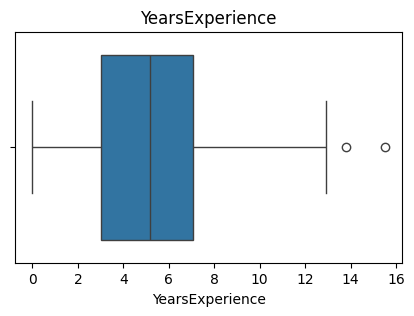

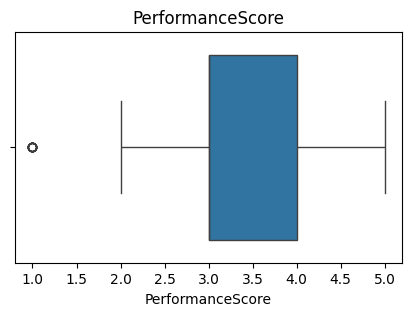

In [16]:
numeric = df.select_dtypes(include=np.number)

for col in numeric.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
for col in numeric.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [19]:
le = LabelEncoder()

for col in ['Gender','Department','Attrition']:
    if col in df.columns:
        df[col+"_Label"] = le.fit_transform(df[col])

In [20]:
df = pd.get_dummies(df,
                    columns=['Department'],
                    drop_first=True)

In [21]:
mm = MinMaxScaler()

scaled = mm.fit_transform(df.select_dtypes(include=np.number))

scaled_df = pd.DataFrame(
    scaled,
    columns=df.select_dtypes(include=np.number).columns
)

scaled_df.head()

,EmployeeID,Age,Salary,YearsExperience,PerformanceScore,Gender_Label,Department_Label,Attrition_Label
0,0.000000,0.068966,0.557944,0.398438,0.333333,0.428571,0.50,0.0
1,0.003236,0.344828,0.493174,0.546875,0.333333,0.428571,0.25,1.0
2,0.006472,0.689655,0.353136,0.460938,0.000000,0.857143,0.75,0.0
3,0.009709,0.344828,0.624965,0.046875,0.333333,0.857143,0.50,0.0
4,0.012945,0.758621,0.211616,0.546875,1.000000,0.714286,0.00,0.0


In [22]:
ss = StandardScaler()

standard = ss.fit_transform(df.select_dtypes(include=np.number))

standard_df = pd.DataFrame(
    standard,
    columns=df.select_dtypes(include=np.number).columns
)

standard_df.head()

,EmployeeID,Age,Salary,YearsExperience,PerformanceScore,Gender_Label,Department_Label,Attrition_Label
0,-1.747305,-1.513930,0.279422,0.003802,-0.530172,-0.312737,0.024735,-0.476523
1,-1.736093,-0.268679,-0.053555,0.679092,-0.530172,-0.312737,-0.670328,2.098534
2,-1.724881,1.287885,-0.773478,0.288135,-1.762863,1.018763,0.719799,-0.476523
3,-1.713669,-0.268679,0.623970,-1.595567,-0.530172,1.018763,0.024735,-0.476523
4,-1.702457,1.599198,-1.501023,0.679092,1.935211,0.574930,-1.365392,-0.476523


In [23]:
corr = df.select_dtypes(include=np.number).corr()

print(corr)

                  EmployeeID       Age    Salary  YearsExperience  \
EmployeeID          1.000000 -0.030490  0.049031         0.050869   
Age                -0.030490  1.000000 -0.079994         0.086640   
Salary              0.049031 -0.079994  1.000000        -0.038614   
YearsExperience     0.050869  0.086640 -0.038614         1.000000   
PerformanceScore    0.009133  0.004911 -0.045404         0.045320   
Gender_Label       -0.070322  0.046818 -0.095731         0.000442   
Department_Label   -0.009251  0.000612  0.031268         0.012859   
Attrition_Label    -0.056392  0.004391  0.055206        -0.128907   

                  PerformanceScore  Gender_Label  Department_Label  \
EmployeeID                0.009133     -0.070322         -0.009251   
Age                       0.004911      0.046818          0.000612   
Salary                   -0.045404     -0.095731          0.031268   
YearsExperience           0.045320      0.000442          0.012859   
PerformanceScore          1.

In [24]:
corr["PerformanceScore"].sort_values(ascending=False)

,PerformanceScore
PerformanceScore,1.000000
Department_Label,0.111897
YearsExperience,0.045320
Gender_Label,0.023502
EmployeeID,0.009133
Age,0.004911
Salary,-0.045404
Attrition_Label,-0.132326


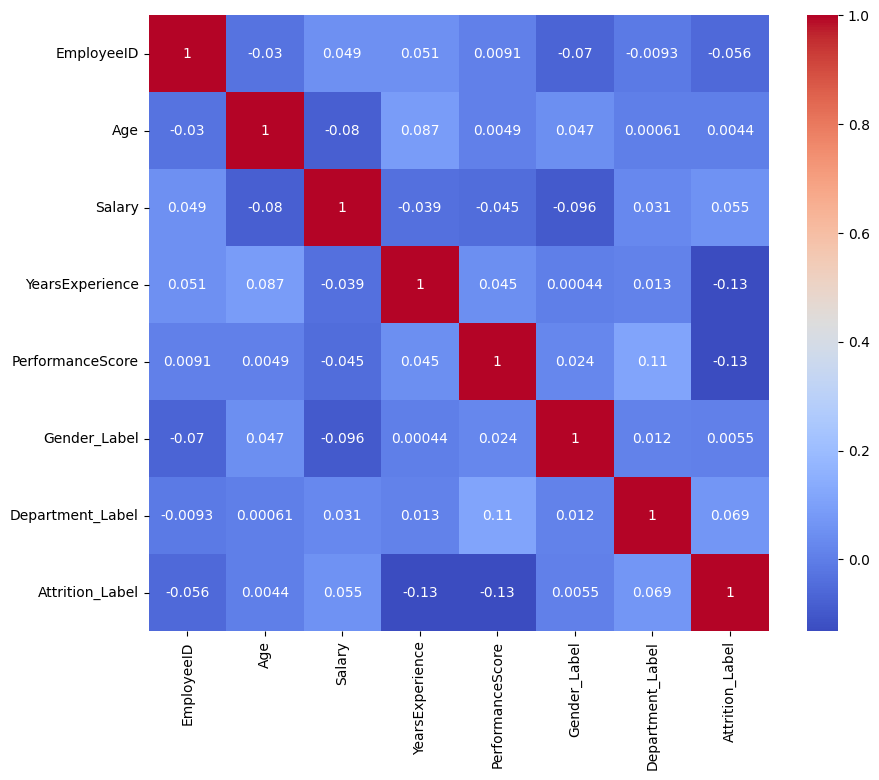

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

In [26]:
df["ExperiencePerAge"] = df["YearsExperience"] / df["Age"]

In [27]:
df["SalaryPerExperience"] = df["Salary"] / (df["YearsExperience"] + 1)

In [28]:
df["Age"] = df["Age"].astype(float)

df.dtypes

,0
EmployeeID,int64
Name,object
Age,float64
Gender,object
JoiningDate,object
City,object
Salary,float64
YearsExperience,float64
PerformanceScore,float64
Attrition,object


In [29]:
df["JoiningDate"] = pd.to_datetime(df["JoiningDate"])

/tmp/ipykernel_3009/554598785.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["JoiningDate"] = pd.to_datetime(df["JoiningDate"])


In [30]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

In [31]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.title()

In [32]:
X = df.drop("Attrition", axis=1)

X = pd.get_dummies(X)

y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(224, 297)
(57, 297)


In [33]:
y = LabelEncoder().fit_transform(y)

In [34]:
smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

print(np.bincount(y_balanced))

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.BoolDType'>, <class 'numpy.dtypes.B

In [36]:
smote = SMOTE(random_state=42)

X = X.drop('JoiningDate', axis=1)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(np.bincount(y_balanced))

[229 229]


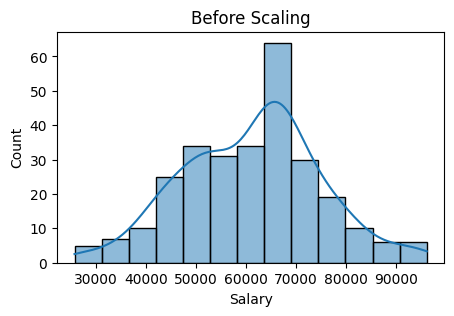

In [37]:
plt.figure(figsize=(5,3))
sns.histplot(df["Salary"], kde=True)
plt.title("Before Scaling")
plt.show()

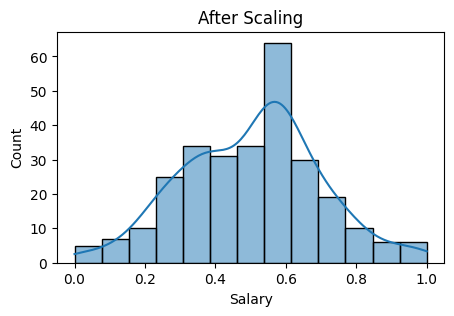

In [38]:
plt.figure(figsize=(5,3))
sns.histplot(scaled_df["Salary"], kde=True)
plt.title("After Scaling")
plt.show()

In [39]:
print("Original Shape")

print(pd.read_csv("employee_dataset.csv").shape)

print("Processed Shape")

print(df.shape)

Original Shape
(310, 11)
Processed Shape
(281, 19)


In [40]:
print("""
Summary

1. Loaded dataset
2. Checked data types
3. Handled missing values
4. Removed duplicates
5. Detected and removed outliers
6. Encoded categorical variables
7. Applied feature scaling
8. Created new features
9. Performed feature selection
10. Generated correlation heatmap
11. Split data into training/testing
12. Applied SMOTE balancing
13. Saved cleaned dataset
""")


Summary

1. Loaded dataset
2. Checked data types
3. Handled missing values
4. Removed duplicates
5. Detected and removed outliers
6. Encoded categorical variables
7. Applied feature scaling
8. Created new features
9. Performed feature selection
10. Generated correlation heatmap
11. Split data into training/testing
12. Applied SMOTE balancing
13. Saved cleaned dataset



In [41]:
df.to_csv("employee_dataset_cleaned.csv", index=False)

In [42]:
from google.colab import files
files.download("employee_dataset_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>